
# Análisis Exploratorio y Visual Analytics de Reseñas IMDb

## Objetivo

Este notebook desarrolla el análisis exploratorio del corpus IMDb Movie Reviews Dataset.

El objetivo es comprender:

- características generales del corpus.
- diferencias entre reseñas positivas y negativas.
- representación semántica mediante embeddings.
- patrones visuales dentro del espacio vectorial.

El notebook forma parte del proyecto:

**Visual Analytics para el análisis semántico y de sentimientos en reseñas cinematográficas mediante técnicas de Procesamiento de Lenguaje Natural.**


## 1. Librerías

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

from sentence_transformers import SentenceTransformer

import warnings
warnings.filterwarnings('ignore')

## 2. Carga del dataset

In [2]:
datos = pd.read_csv("IMDB Dataset.csv")

datos.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
datos.shape

(50000, 2)


Cada registro representa una reseña individual de una película.

Variables principales:

- review: texto escrito por el usuario.
- sentiment: etiqueta positiva o negativa.


## 3. Calidad inicial de datos

In [4]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
datos.isnull().sum()

,0
review,0
sentiment,0


In [6]:
datos.duplicated().sum()

np.int64(418)

## 4. Distribución de sentimientos

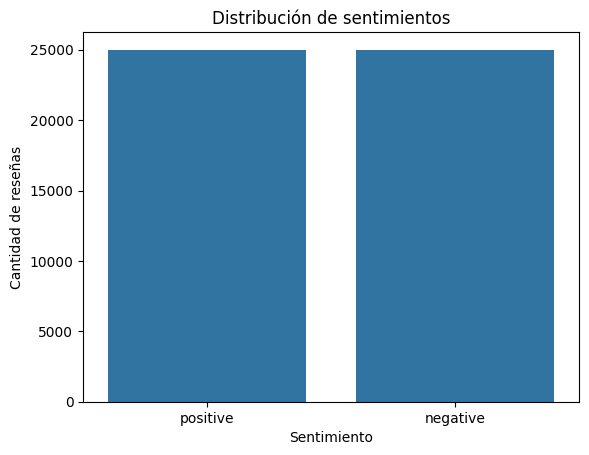

In [7]:
sns.countplot(
    data=datos,
    x="sentiment"
)

plt.title("Distribución de sentimientos")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de reseñas")
plt.show()

## 5. Características del texto

In [8]:
datos["longitud"] = datos["review"].apply(
    lambda x: len(x.split())
)

datos.groupby("sentiment")["longitud"].describe()

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,25000.0,229.46456,164.947795,4.0,128.0,174.0,278.0,1522.0
positive,25000.0,232.84932,177.497046,10.0,125.0,172.0,284.0,2470.0


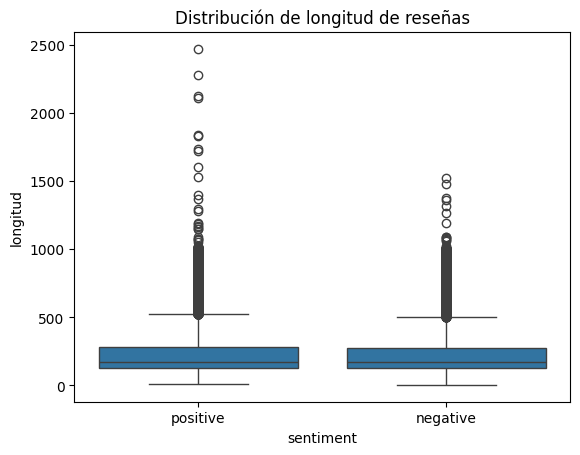

In [9]:
sns.boxplot(
    data=datos,
    x="sentiment",
    y="longitud"
)

plt.title("Distribución de longitud de reseñas")
plt.show()

## 6. Análisis TF-IDF

In [10]:
vectorizador = TfidfVectorizer(
    max_features=5000
)

X_tfidf = vectorizador.fit_transform(
    datos["review"]
)

X_tfidf.shape

(50000, 5000)


TF-IDF permite identificar términos relevantes dentro del corpus.

Esta representación será utilizada como referencia frente a representaciones semánticas basadas en embeddings.


## 7. Generación de embeddings

In [11]:
modelo_embedding = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

muestra = datos.sample(
    2000,
    random_state=42
)

embeddings = modelo_embedding.encode(
    muestra["review"].tolist(),
    normalize_embeddings=True
)

embeddings.shape

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

(2000, 384)

## 8. Visualización semántica mediante PCA

In [12]:
pca = PCA(
    n_components=2,
    random_state=42
)

proyeccion = pca.fit_transform(
    embeddings
)

visual = pd.DataFrame({
    "PCA1": proyeccion[:,0],
    "PCA2": proyeccion[:,1],
    "sentiment": muestra["sentiment"].values
})

visual.head()

,PCA1,PCA2,sentiment
0,0.225401,-0.350018,positive
1,0.194521,-0.278403,positive
2,-0.050800,-0.096883,negative
3,0.237937,0.109534,positive
4,0.100531,-0.000858,negative


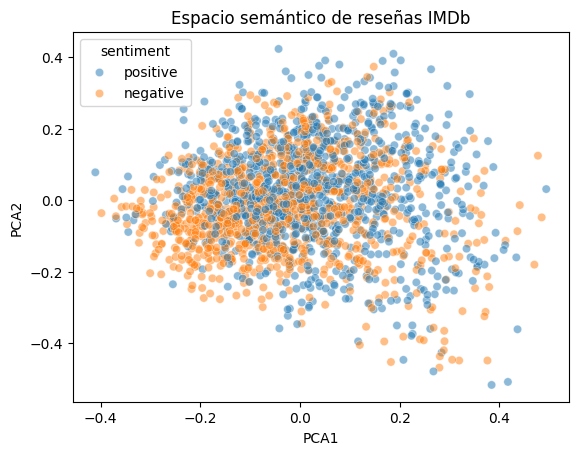

In [13]:
sns.scatterplot(
    data=visual,
    x="PCA1",
    y="PCA2",
    hue="sentiment",
    alpha=0.5
)

plt.title(
    "Espacio semántico de reseñas IMDb"
)

plt.show()


## Interpretación

Cada punto representa una reseña transformada en un vector semántico.

La reducción PCA permite observar una representación bidimensional del espacio original de embeddings.

La cercanía entre puntos indica similitud semántica.



## 9. Conclusiones preliminares

El análisis exploratorio permite identificar:

- diferencias generales entre sentimientos.
- características del lenguaje utilizado.
- estructuras semánticas dentro del corpus.

Estas observaciones servirán como base para la propuesta final de Visual Analytics.
